In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/newsData/raw_analyst_ratings.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


,Unnamed: 0
count,1.407328e+06
mean,7.072454e+05
std,4.081009e+05
min,0.000000e+00
25%,3.538128e+05
50%,7.072395e+05
75%,1.060710e+06
max,1.413848e+06


In [7]:
df ["headline_length"] = df["headline"].apply(len)
df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

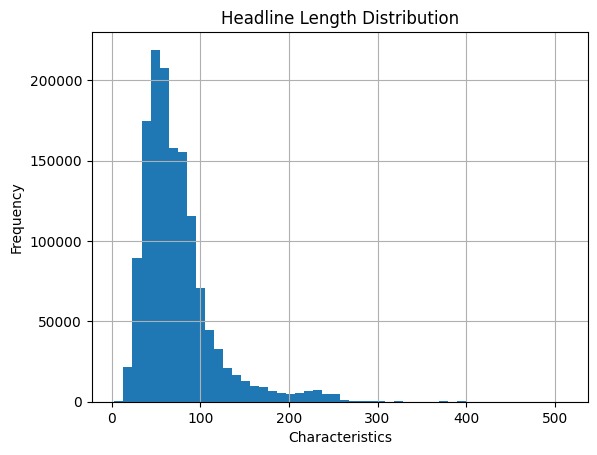

In [8]:
import matplotlib.pyplot as plt

df["headline_length"].hist(bins=50)
plt.title("Headline Length Distribution")
plt.xlabel("Characteristics")
plt.ylabel("Frequency")
plt.show()

In [9]:
publisher_counts = df["publisher"].value_counts()
publisher_counts.head(10)


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

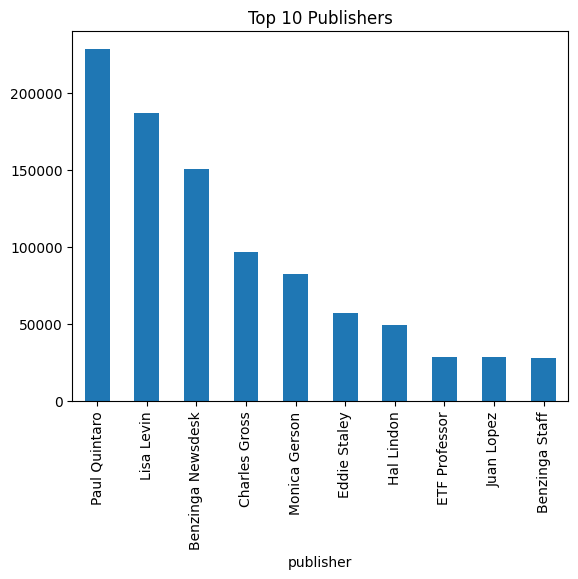

In [10]:
publisher_counts.head(10).plot(kind="bar")
plt.title("Top 10 Publishers")
plt.show()

In [11]:
df["domain"] = df["publisher"].str.extract(r'@(.+)')

df["domain"].value_counts().head()

domain
benzinga.com      7937
gmail.com          139
andyswan.com         5
investdiva.com       2
tothetick.com        2
Name: count, dtype: int64

In [12]:
df["date"].head(20)
df["date"].unique()[:20]
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["date"].isna().sum()
df = df.dropna(subset=["date"])
daily_counts = df.groupby(df["date"].dt.date).size()
weekly_counts = df.resample("W", on="date").size()

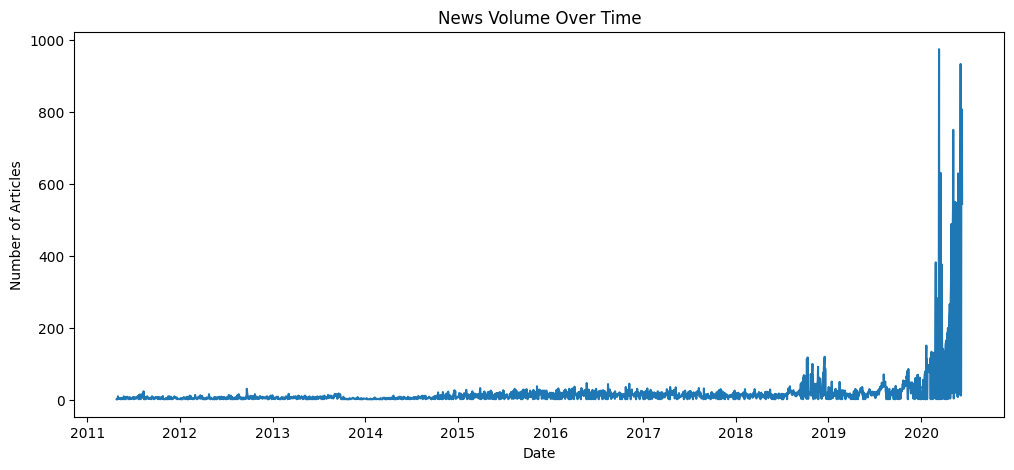

In [13]:
import matplotlib.pyplot as plt

daily_counts.plot(figsize=(12,5))
plt.title("News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df["headline"])

words = vectorizer.get_feature_names_out()

In [15]:
import numpy as np

scores = np.asarray(X.mean(axis=0)).ravel()

top_words = pd.DataFrame({
    "word": words,
    "score": scores
}).sort_values(by="score", ascending=False)

top_words.head(20)

,word,score
19250,stocks,0.054904
21504,week,0.047535
1739,52,0.047509
10999,hit,0.042130
13090,lows,0.030421
20072,thursday,0.023650
10953,highs,0.022247
9896,friday,0.019999
13383,market,0.019651
18370,shares,0.019072


In [16]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(stop_words='english')

X_counts = count_vectorizer.fit_transform(df["headline"])

lda = LatentDirichletAllocation(n_components=5)

lda.fit(X_counts)

LatentDirichletAllocation(n_components=5)

In [17]:
words = count_vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"Topic {i}")
    print([words[j] for j in topic.argsort()[-10:]])

Topic 0
['buy', 'market', 'lowers', 'raises', 'moving', 'session', 'stocks', 'maintains', 'target', 'price']
Topic 1
['set', 'new', 'thursday', 'highs', 'yesterday', 'lows', 'hit', '52', 'week', 'stocks']
Topic 2
['q2', 'reports', 'q4', 'est', 'vs', 'yoy', 'q1', 'estimate', 'sales', 'eps']
Topic 3
['etf', 'share', 'says', 'announces', 'mid', 'reports', 'earnings', 'update', 'market', 'shares']
Topic 4
['economic', 'coronavirus', 'etfs', 'following', 'lower', 'amid', 'higher', 'companies', 'shares', 'trading']


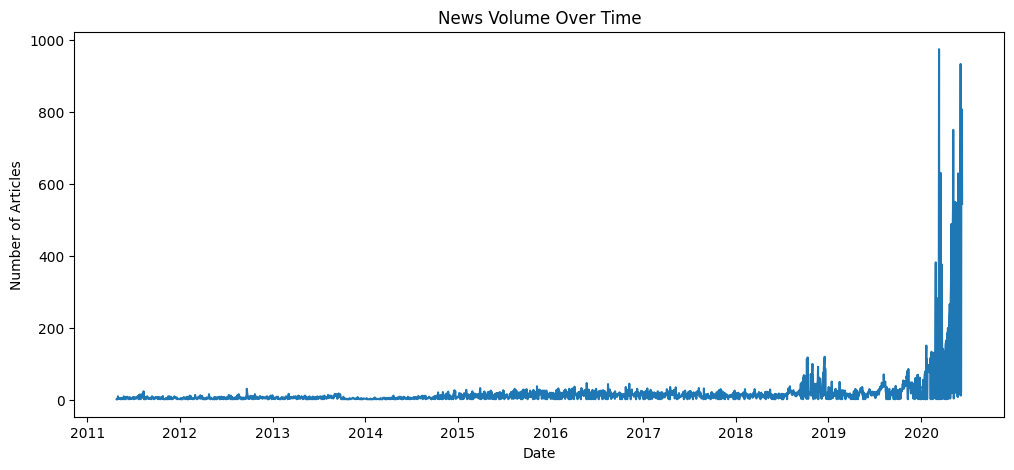

In [18]:
df["date"] = pd.to_datetime(df["date"])
daily_news = df.groupby(df["date"].dt.date).size()

daily_news.plot(figsize=(12,5))

plt.title("News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

<Axes: xlabel='hour'>

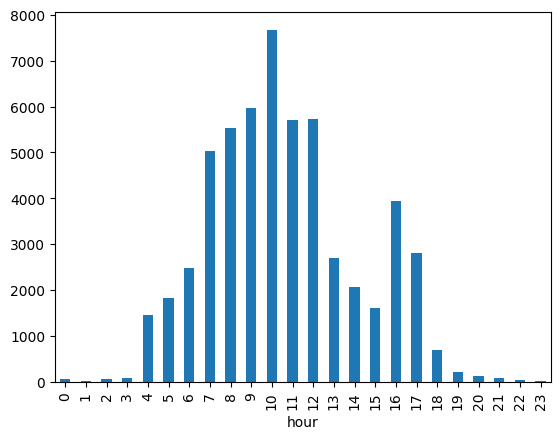

In [19]:
df["hour"] = df["date"].dt.hour

df["hour"].value_counts().sort_index().plot(kind="bar")